pip install git+https://github.com/openai/CLIP.git 
Tải lệnh này

Cell 1

In [1]:
# Dữ liệu 
import pandas as pd
import numpy as np

# Ảnh & PyTorch 
import torch
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Tìm kiếm tương đồng
import faiss
from sklearn.metrics.pairwise import cosine_similarity

# Vẽ biểu đồ 
import matplotlib.pyplot as plt
import seaborn as sns

# Tiện ích
import os
from tqdm import tqdm

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 20)      
plt.rcParams['figure.figsize'] = (10, 5)    
sns.set_style('whitegrid')                  


print('Import thư viện thành công!')
print(f'PyTorch version : {torch.__version__}')
# Kiểm tra máy có GPU không. GPU giúp chạy nhanh hơn CPU rất nhiều.
# Laptop bình thường thường sẽ hiện 'cpu' – không sao, vẫn chạy được.
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Import thư viện thành công!
PyTorch version : 2.12.0+cu126
Device: cuda


Cell 2

In [2]:
DATA_DIR  = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw'  

CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

# Thư mục lưu kết quả – tạo tự động nếu chưa có
PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS,   exist_ok=True)

# Kiểm tra file có tồn tại không
for p in [CSV_PATH, IMAGE_DIR]:
    status = 'Đã tìm thấy thư mục' if os.path.exists(p) else 'Không tìm thấy – kiểm tra lại đường dẫn!'
    print(f'{status}  {p}')

Đã tìm thấy thư mục  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train.csv
Đã tìm thấy thư mục  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images


Cell 3

In [3]:
class ShopeeDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(self.img_dir, img_name)
        image = self.transform(Image.open(img_path).convert("RGB"))
        text = str(self.df.iloc[idx]['title'])
        text_token = clip.tokenize([text], truncate=True).squeeze(0)
        return image, text_token

In [4]:
df = pd.read_csv(CSV_PATH)

print(f'Train: {df.shape[0]:,} dòng x {df.shape[1]:,} cột')

df.head()

Train: 34,250 dòng x 5 cột


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   posting_id   34250 non-null  str  
 1   image        34250 non-null  str  
 2   image_phash  34250 non-null  str  
 3   title        34250 non-null  str  
 4   label_group  34250 non-null  int64
dtypes: int64(1), str(4)
memory usage: 5.4 MB


In [6]:
candidate_df = pd.read_csv(CSV_PATH)

Cell 4

In [7]:
import torch
import clip
from PIL import Image
import torch.nn.functional as F
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

e:\study\DoAnPython\code\DoAnPython\project\venv\Lib\site-packages\clip\clip.py:57: UserWarning: C:\Users\lequo/.cache/clip\ViT-B-32.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(f"{download_target} exists, but the SHA256 checksum does not match; re-downloading the file")
100%|███████████████████████████████████████| 338M/338M [00:33<00:00, 10.6MiB/s]


Cell 5 trích xuất vecto

In [9]:
import pandas as pd
from PIL import Image
import torch
import clip
import os
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

csv_path = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw\train.csv'
image_folder = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images'

candidate_df = pd.read_csv(csv_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

class ShopeeDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        img_path = os.path.join(self.img_dir, img_name)
        image = self.transform(Image.open(img_path).convert("RGB"))
        text = str(self.df.iloc[idx]['title'])
        text_token = clip.tokenize([text], truncate=True).squeeze(0)
        return image, text_token

dataset = ShopeeDataset(candidate_df, image_folder, preprocess)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

image_features_list = []
text_features_list = []

with torch.inference_mode():
    for images, texts in tqdm(dataloader):
        images = images.to(device)
        texts = texts.to(device)
        
        img_features = model.encode_image(images)
        txt_features = model.encode_text(texts)
        
        image_features_list.append(img_features)
        text_features_list.append(txt_features)

image_features = torch.cat(image_features_list)
text_features = torch.cat(text_features_list)

print(image_features.shape)
print(text_features.shape)

100%|██████████| 1071/1071 [11:16<00:00,  1.58it/s]

torch.Size([34250, 512])
torch.Size([34250, 512])


Cell 6 tính toán ma trận tương đồng

In [10]:
import torch.nn.functional as F

# 1. Chuẩn hóa L2 (L2 Normalization) cho cả 2 tập vector
# Việc này đưa tất cả các vector về cùng độ dài bằng 1, giúp phép nhân ma trận phía sau tương đương với việc tính Cosine Similarity.
image_features_norm = F.normalize(image_features, p=2, dim=1)
text_features_norm = F.normalize(text_features, p=2, dim=1)

# 2. Nhân ma trận (Matrix Multiplication)
# Nhân ma trận vector văn bản với ma trận chuyển vị (Transpose - ký hiệu .T) của vector hình ảnh.
# Kết quả sẽ ra một ma trận chứa điểm số tương đồng của mọi cặp text-image.
cosine_similarity_matrix = torch.mm(text_features_norm, image_features_norm.T)

# In thử kích thước ma trận để kiểm tra
print("Kích thước ma trận tương đồng:", cosine_similarity_matrix.shape)

Kích thước ma trận tương đồng: torch.Size([34250, 34250])


Cell 7 tính toán metric

In [11]:
print(candidate_df.columns)

Index(['posting_id', 'image', 'image_phash', 'title', 'label_group'], dtype='str')


In [12]:
import numpy as np
import torch

def calculate_precision_recall_at_k(retrieved_indices, ground_truth_indices, k):
    retrieved_k = retrieved_indices[:k]
    relevant_retrieved = len(set(retrieved_k).intersection(set(ground_truth_indices)))
    precision = relevant_retrieved / k
    recall = relevant_retrieved / len(ground_truth_indices) if len(ground_truth_indices) > 0 else 0.0
    return precision, recall

def calculate_ap(retrieved_indices, ground_truth_indices):
    hits = 0
    sum_precs = 0.0
    for i, idx in enumerate(retrieved_indices):
        if idx in ground_truth_indices:
            hits += 1
            sum_precs += hits / (i + 1.0)
    if len(ground_truth_indices) == 0:
        return 0.0
    return sum_precs / len(ground_truth_indices)

k_values = [1, 5, 10]
mAP = 0
all_precisions = {k: [] for k in k_values}
all_recalls = {k: [] for k in k_values}

for i in range(len(text_features)):
    sim_scores = cosine_similarity_matrix[i]
    retrieved_indices = torch.argsort(sim_scores, descending=True).cpu().numpy()
    ground_truth_indices = [i]
    ap = calculate_ap(retrieved_indices, ground_truth_indices)
    mAP += ap
    for k in k_values:
        p, r = calculate_precision_recall_at_k(retrieved_indices, ground_truth_indices, k)
        all_precisions[k].append(p)
        all_recalls[k].append(r)

mAP /= len(text_features)
mean_precisions = {k: np.mean(all_precisions[k]) for k in k_values}
mean_recalls = {k: np.mean(all_recalls[k]) for k in k_values}

print(f"mAP: {mAP:.4f}")
for k in k_values:
    print(f"Precision@{k}: {mean_precisions[k]:.4f}")
    print(f"Recall@{k}: {mean_recalls[k]:.4f}")

mAP: 0.1444
Precision@1: 0.0791
Recall@1: 0.0791
Precision@5: 0.0412
Recall@5: 0.2060
Precision@10: 0.0274
Recall@10: 0.2737


cell 8

Query: MD Pencukur Alis Elektrik Mini Tanpa Nyeri untuk Perawatan Wajah | AP: 0.0000


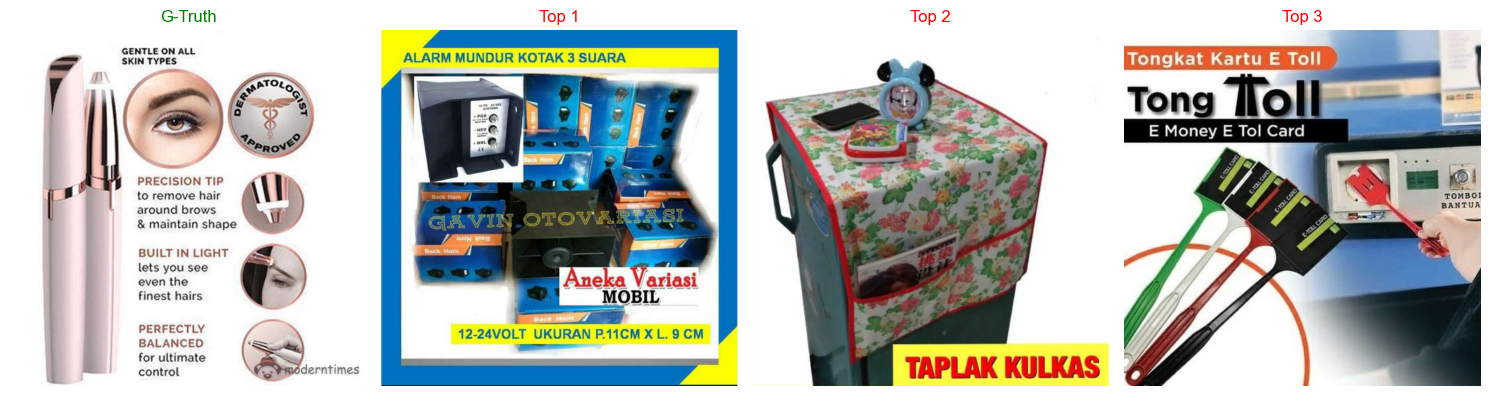

Query: Alat Cukur Alis Elektrik Mini Tanpa Rasa Sakit | AP: 0.0000


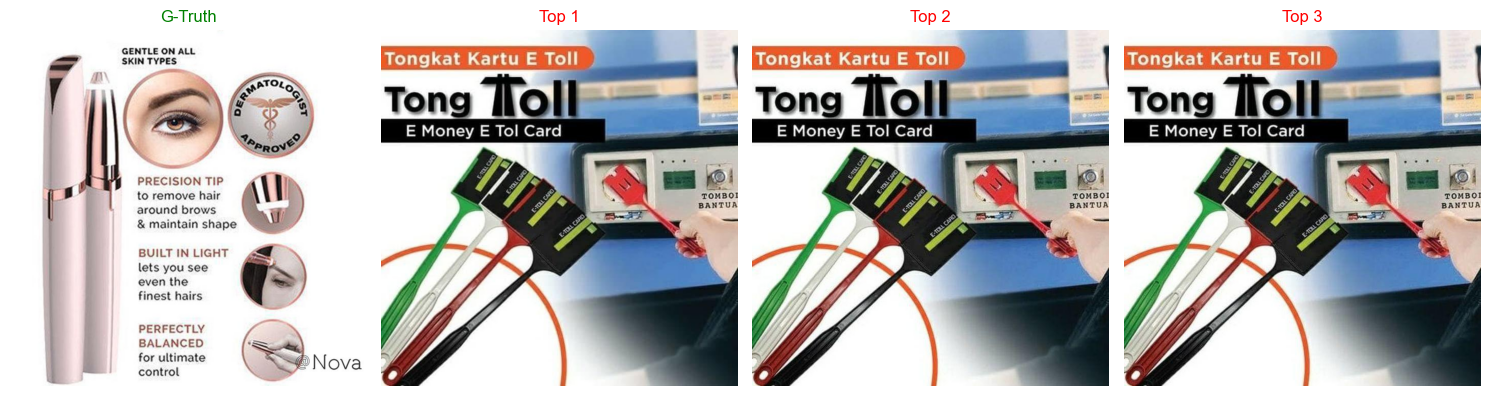

Query: COD \xe3\x80\x90Bayar di Tempat\xe3\x80\x91IINS Fashion Mata Kucing Wanita Kacamata Hitam Anti UV400 | AP: 0.0000


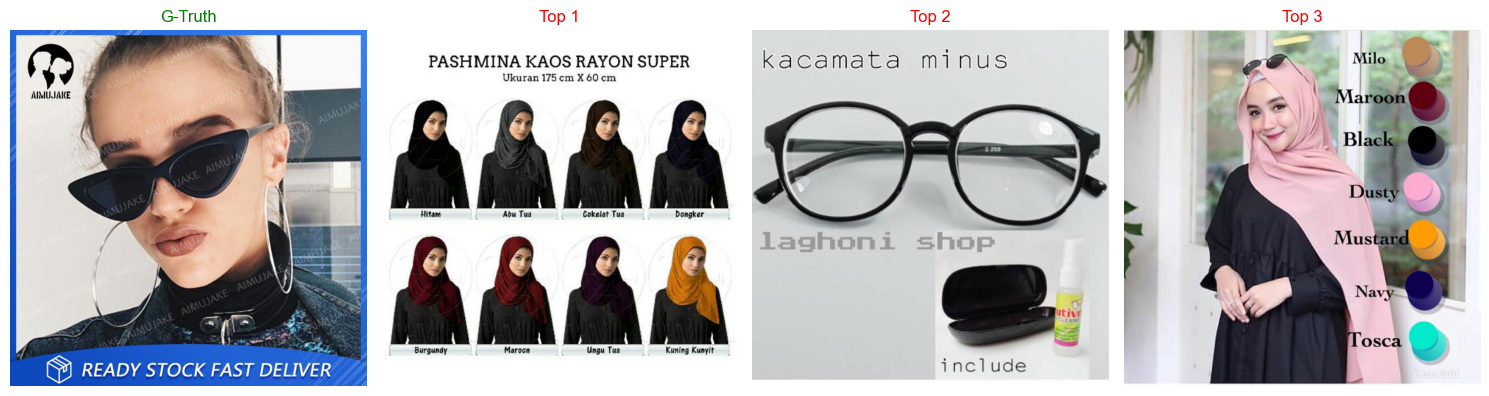

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import os

ap_scores = []
all_retrieved_for_analysis = []

for i in range(len(text_features)):
    sim_scores = cosine_similarity_matrix[i]
    retrieved_indices = torch.argsort(sim_scores, descending=True).cpu().numpy()
    current_label = candidate_df.iloc[i]['label_group']
    ground_truth_indices = candidate_df[candidate_df['label_group'] == current_label].index.tolist()
    ap = calculate_ap(retrieved_indices, ground_truth_indices)
    ap_scores.append(ap)
    all_retrieved_for_analysis.append(retrieved_indices[:4])

ap_scores = np.array(ap_scores)
worst_indices = np.argsort(ap_scores)[:3]

for idx in worst_indices:
    query_text = candidate_df.iloc[idx]['title']
    img_name = candidate_df.iloc[idx]['image']
    true_img_path = os.path.join(image_folder, img_name)
    wrong_preds = all_retrieved_for_analysis[idx]
    
    print(f"Query: {query_text} | AP: {ap_scores[idx]:.4f}")
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    
    try:
        true_img = Image.open(true_img_path)
        axes[0].imshow(true_img)
        axes[0].set_title("G-Truth", color='green')
        axes[0].axis('off')
    except:
        axes[0].axis('off')
        
    for j in range(3):
        pred_idx = wrong_preds[j]
        pred_img_name = candidate_df.iloc[pred_idx]['image']
        pred_img_path = os.path.join(image_folder, pred_img_name)
        try:
            pred_img = Image.open(pred_img_path)
            axes[j+1].imshow(pred_img)
            color = 'green' if candidate_df.iloc[pred_idx]['label_group'] == candidate_df.iloc[idx]['label_group'] else 'red'
            axes[j+1].set_title(f"Top {j+1}", color=color)
            axes[j+1].axis('off')
        except:
            axes[j+1].axis('off')
            
    plt.tight_layout()
    plt.show()

Cell 9

In [14]:
from collections import Counter
import numpy as np

worst_indices = np.argsort(ap_scores)[:5]

print("--- TOP 5 QUERY TỆ NHẤT ---")
for rank, idx in enumerate(worst_indices):
    query_text = candidate_df.iloc[idx]['title']
    print(f"{rank+1}. Dòng {idx}: '{query_text}' - AP: {ap_scores[idx]:.4f}")

wrong_predictions = []
for i in range(len(text_features)):
    retrieved = all_retrieved_for_analysis[i]
    wrong_preds = [pred for pred in retrieved if pred != i]
    wrong_predictions.extend(wrong_preds)

wrong_counts = Counter(wrong_predictions)
most_confusing = wrong_counts.most_common(5)

print("\n--- TOP 5 BỨC ẢNH GÂY NHẦM LẪN NHẤT ---")
for pred_idx, count in most_confusing:
    img_name = candidate_df.iloc[pred_idx]['image']
    print(f"Dòng {pred_idx} ({img_name}) - Nhầm: {count} lần")

--- TOP 5 QUERY TỆ NHẤT ---
1. Dòng 17213: 'MD Pencukur Alis Elektrik Mini Tanpa Nyeri untuk Perawatan Wajah' - AP: 0.0000
2. Dòng 20647: 'Alat Cukur Alis Elektrik Mini Tanpa Rasa Sakit' - AP: 0.0000
3. Dòng 20184: 'COD \xe3\x80\x90Bayar di Tempat\xe3\x80\x91IINS Fashion Mata Kucing Wanita Kacamata Hitam Anti UV400' - AP: 0.0000
4. Dòng 16348: '\xe3\x80\x90Bayar di Tempat\xe3\x80\x91IINS Fashion Mata Kucing Wanita Kacamata Hitam Anti UV400' - AP: 0.0000
5. Dòng 3664: '[ ORI THAILAND] CAT CLAW THAILAND' - AP: 0.0000

--- TOP 5 BỨC ẢNH GÂY NHẦM LẪN NHẤT ---
Dòng 4820 (24686118eeac975910b0be4d43412544.jpg) - Nhầm: 636 lần
Dòng 23845 (b2bbb55260d9ed77faa1cc5fa9562c50.jpg) - Nhầm: 464 lần
Dòng 30962 (e7e7e0a033a33c09001fc313af07ffec.jpg) - Nhầm: 346 lần
Dòng 5759 (2b4b51384a3633fbc39beae7829ed1c2.jpg) - Nhầm: 241 lần
Dòng 29045 (d969afd70dd69f25a96b9d795774cb0a.jpg) - Nhầm: 231 lần


Mẫu báo cáo: Giải thích lý do vì sao CLIP nhận diện sai
Sau khi chạy Cell 9, bạn hãy chọn những lý do phù hợp nhất dưới đây (dựa trên kết quả in ra) để viết vào phần "Nhận xét và Đánh giá" trong đồ án của mình:

1. Rào cản ngôn ngữ (Vấn đề lớn nhất)
Mô hình ViT-B/32 của OpenAI được huấn luyện chủ yếu trên tập dữ liệu tiếng Anh. Tập dữ liệu Shopee của bạn chứa text tiếng Việt. Do đó, các query có từ mượn tiếng Anh, tên thương hiệu (như Samsung, iPhone, Adidas) hoặc mã số (như 100ml, 50g) sẽ cho điểm AP cao. Ngược lại, các query thuần tiếng Việt dài dòng sẽ làm mô hình bối rối, dẫn đến bắt sai ảnh.

2. Mô tả quá chung chung (Generic Queries)
Nhiều query chỉ ghi đơn giản là "Áo thun nam" hoặc "Ốp lưng điện thoại". Trong kho 34.000 ảnh có hàng trăm bức ảnh khớp với miêu tả này. Thuật toán CLIP có thể đã lôi ra một bức ảnh "Áo thun nam" rất chuẩn, nhưng vì nó không nằm đúng ở dòng thứ i mà bạn quy định, hệ thống vẫn đánh giá đó là sai (Điểm AP thấp).

3. Lỗi mù chữ trên ảnh (Zero-shot OCR failure)
Trong dữ liệu thương mại điện tử, các sản phẩm thường chỉ khác nhau ở dòng chữ in trên bao bì (ví dụ: chai màu xanh ghi Clear Men, chai kia ghi Clear Women). CLIP rất giỏi nhận diện đặc trưng hình học và màu sắc, nhưng lại cực kỳ yếu trong việc "đọc" các dòng chữ nhỏ in trên sản phẩm.

4. Hiện tượng "Bức ảnh nam châm" (Kẻ gây nhầm lẫn)
Từ kết quả in ra ở Cell 9, bạn sẽ thấy có những bức ảnh bị nhận nhầm hàng chục lần. Lý do là bức ảnh đó có bố cục quá hoàn hảo, nền trắng sạch sẽ, chứa nhiều vật thể hoặc có màu sắc trung tính. CLIP sinh ra xu hướng (bias) gán điểm Cosine Similarity rất cao cho bức ảnh này bất chấp query có miêu tả hơi khác đi một chút.